# Multivariate and Multi-Step Forecasting

## 1. Why This Notebook Changes the Forecasting Problem

The previous notebooks predicted:

```text
one variable
one step ahead
```

Real forecasting often requires:

```text
many input variables
+
many future steps
```

This notebook develops:

- **multivariate forecasting**,
- **multi-step forecasting**,
- **recursive forecasting**,
- **direct multi-output forecasting**,
- **horizon-wise evaluation**.

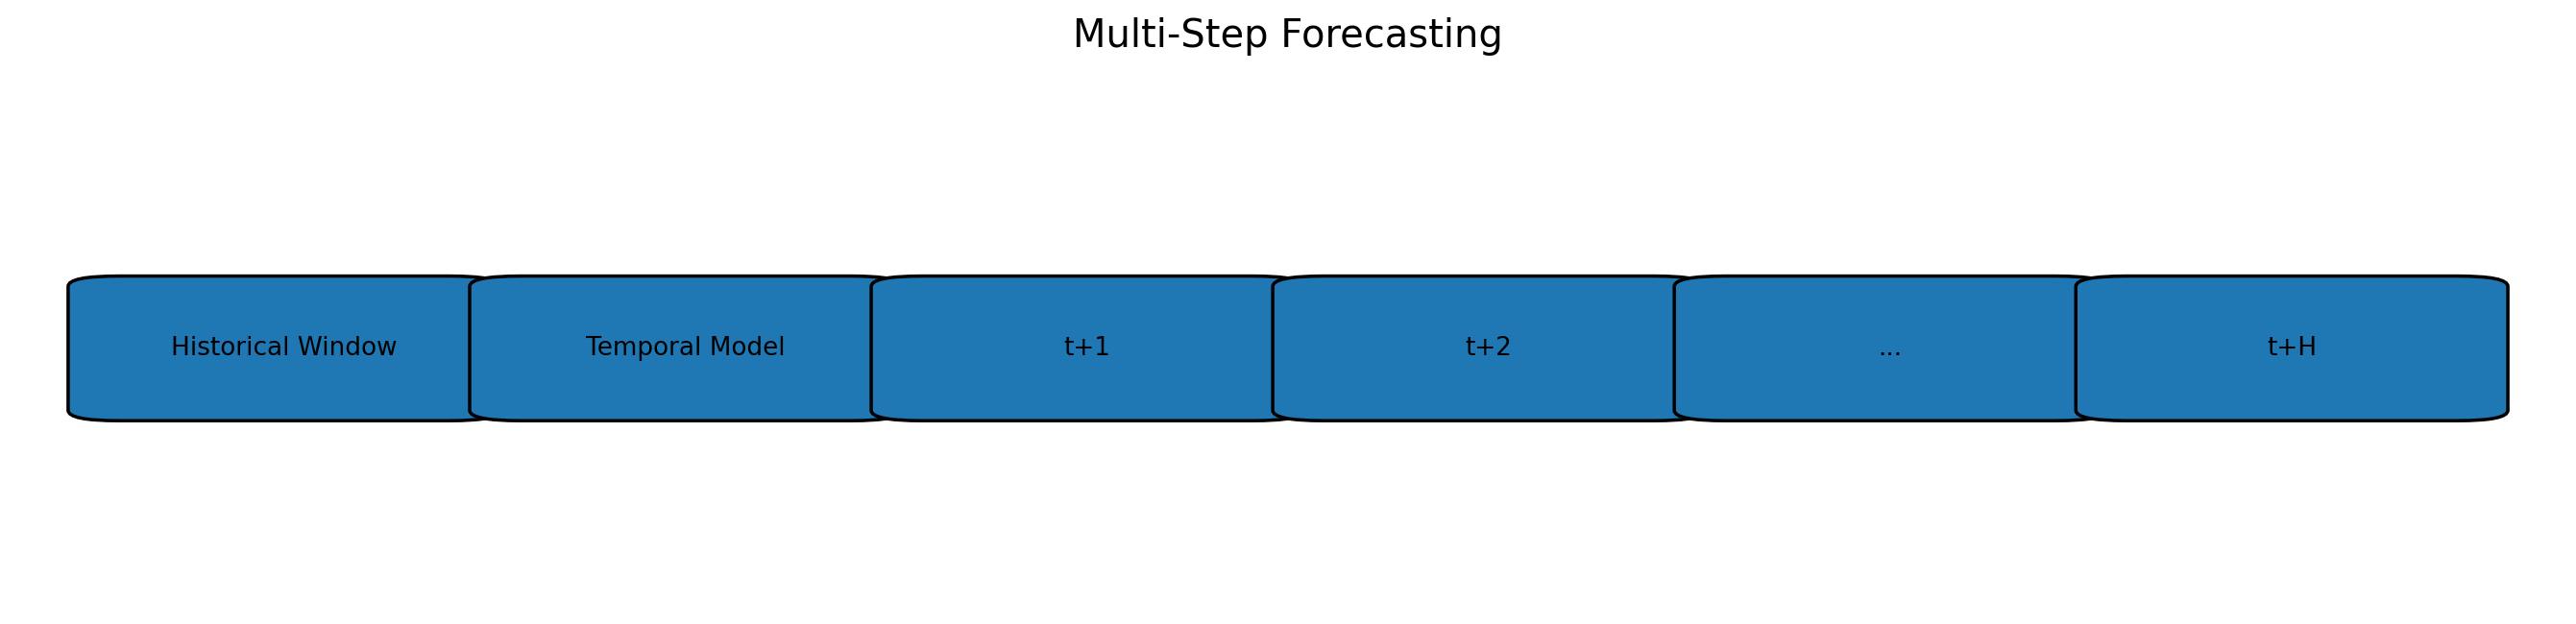

## 2. Learning Objectives

By the end of this notebook, you should be able to:

- distinguish univariate and multivariate forecasting,
- distinguish single-step and multi-step forecasting,
- explain recursive and direct forecasting,
- understand error accumulation,
- construct multivariate temporal windows,
- scale several features without leakage,
- build a direct multi-output LSTM,
- build a recursive one-step LSTM,
- compare univariate and multivariate inputs,
- evaluate MAE separately at each forecast horizon,
- visualize forecast degradation across the horizon,
- understand why future covariates require special treatment,
- explain how sequence-to-sequence forecasting extends these ideas.

## 3. Forecasting Setup

We use:

```text
Historical context = 72 hours
Forecast horizon   = 24 hours
```

The model sees the previous three days and predicts the next full day.

In [23]:
lookback = 72

forecast_horizon = 24

print("Lookback:")
print(
    lookback
)

print()

print("Forecast horizon:")
print(
    forecast_horizon
)

Lookback:
72

Forecast horizon:
24


## 4. Imports and Reproducibility

In [24]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader

np.random.seed(42)

torch.manual_seed(42)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:")
print(device)

Device:
cpu


## 5. Load the Dataset

In [25]:
"""data_path = "data/synthetic_hourly_demand.csv"

data = pd.read_csv(
    data_path
)

data["timestamp"] = pd.to_datetime(
    data["timestamp"]
)

data = data.set_index(
    "timestamp"
)

print("Dataset shape:")
print(
    data.shape
)

print()

print(
    data.head()
)"""

'data_path = "data/synthetic_hourly_demand.csv"\n\ndata = pd.read_csv(\n    data_path\n)\n\ndata["timestamp"] = pd.to_datetime(\n    data["timestamp"]\n)\n\ndata = data.set_index(\n    "timestamp"\n)\n\nprint("Dataset shape:")\nprint(\n    data.shape\n)\n\nprint()\n\nprint(\n    data.head()\n)'

In [26]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

data = pd.read_csv(file_name)

data["timestamp"] = pd.to_datetime(data["timestamp"])

data = data.set_index("timestamp")

print("Dataset shape:")
print(data.shape)

print()

print(data.head())

Saving synthetic_hourly_demand.csv to synthetic_hourly_demand (1).csv
Dataset shape:
(4320, 3)

                        demand  temperature   humidity
timestamp                                             
2024-01-01 00:00:00  57.677652    14.245071  68.643648
2024-01-01 01:00:00  55.247391    13.548160  67.526067
2024-01-01 02:00:00  60.693636    15.476342  69.414668
2024-01-01 03:00:00  59.486114    17.981244  61.808302
2024-01-01 04:00:00  61.259739    16.898770  60.423073


## 6. Add Calendar Features

We include cyclical time features so the model can represent daily and weekly position.

These are known from the timestamp itself and do not leak future target values.

In [27]:
data["hour"] = data.index.hour

data["day_of_week"] = data.index.dayofweek

data["hour_sin"] = np.sin(
    2.0
    * np.pi
    * data["hour"]
    / 24.0
)

data["hour_cos"] = np.cos(
    2.0
    * np.pi
    * data["hour"]
    / 24.0
)

data["day_sin"] = np.sin(
    2.0
    * np.pi
    * data["day_of_week"]
    / 7.0
)

data["day_cos"] = np.cos(
    2.0
    * np.pi
    * data["day_of_week"]
    / 7.0
)

print(
    data[
        [
            "demand",
            "temperature",
            "humidity",
            "hour_sin",
            "hour_cos",
            "day_sin",
            "day_cos"
        ]
    ].head()
)

                        demand  temperature   humidity  hour_sin  hour_cos  \
timestamp                                                                    
2024-01-01 00:00:00  57.677652    14.245071  68.643648  0.000000  1.000000   
2024-01-01 01:00:00  55.247391    13.548160  67.526067  0.258819  0.965926   
2024-01-01 02:00:00  60.693636    15.476342  69.414668  0.500000  0.866025   
2024-01-01 03:00:00  59.486114    17.981244  61.808302  0.707107  0.707107   
2024-01-01 04:00:00  61.259739    16.898770  60.423073  0.866025  0.500000   

                     day_sin  day_cos  
timestamp                              
2024-01-01 00:00:00      0.0      1.0  
2024-01-01 01:00:00      0.0      1.0  
2024-01-01 02:00:00      0.0      1.0  
2024-01-01 03:00:00      0.0      1.0  
2024-01-01 04:00:00      0.0      1.0  


## 7. Define Input Features

### Univariate model

Uses only historical demand.

### Multivariate model

Uses:

```text
demand
temperature
humidity
hour_sin
hour_cos
day_sin
day_cos
```

The model receives only **historical** values from these variables in this notebook.

In [28]:
multivariate_columns = [
    "demand",
    "temperature",
    "humidity",
    "hour_sin",
    "hour_cos",
    "day_sin",
    "day_cos"
]

print("Number of multivariate features:")
print(
    len(
        multivariate_columns
    )
)

Number of multivariate features:
7


## 8. Chronological Split

In [29]:
number_of_rows = len(
    data
)

train_end = int(
    number_of_rows * 0.70
)

validation_end = int(
    number_of_rows * 0.85
)

train_data = data.iloc[
    :train_end
].copy()

validation_data = data.iloc[
    train_end:validation_end
].copy()

test_data = data.iloc[
    validation_end:
].copy()

print("Training rows:")
print(
    len(
        train_data
    )
)

print()

print("Validation rows:")
print(
    len(
        validation_data
    )
)

print()

print("Test rows:")
print(
    len(
        test_data
    )
)

Training rows:
3024

Validation rows:
648

Test rows:
648


## 9. Scale Continuous Features Using Training Data Only

For each continuous variable, calculate:

```text
training mean
training standard deviation
```

and reuse those values for validation and test.

In [30]:
continuous_columns = [
    "demand",
    "temperature",
    "humidity"
]

feature_means = {}

feature_stds = {}

for column in continuous_columns:

    feature_means[
        column
    ] = train_data[
        column
    ].mean()

    feature_stds[
        column
    ] = train_data[
        column
    ].std()

    print(
        column,
        "| mean:",
        feature_means[
            column
        ],
        "| std:",
        feature_stds[
            column
        ]
    )

demand | mean: 58.131815796315834 | std: 7.436389347851541
temperature | mean: 21.044499543875613 | std: 5.533285575169095
humidity | mean: 59.93111586329634 | std: 6.824760455915643


In [31]:
train_scaled = train_data.copy()

validation_scaled = validation_data.copy()

test_scaled = test_data.copy()

for column in continuous_columns:

    train_scaled[
        column
    ] = (
        train_scaled[
            column
        ]
        - feature_means[
            column
        ]
    ) / feature_stds[
        column
    ]

    validation_scaled[
        column
    ] = (
        validation_scaled[
            column
        ]
        - feature_means[
            column
        ]
    ) / feature_stds[
        column
    ]

    test_scaled[
        column
    ] = (
        test_scaled[
            column
        ]
        - feature_means[
            column
        ]
    ) / feature_stds[
        column
    ]

## 10. Build Multi-Step Windows

Each sample contains:

```text
X:
72 historical timesteps

y:
24 future demand values
```

In [32]:
def create_multistep_windows(
    feature_values,
    target_values,
    lookback,
    forecast_horizon
):

    X = []

    y = []

    maximum_start = (
        len(
            feature_values
        )
        - lookback
        - forecast_horizon
        + 1
    )

    for start_index in range(
        maximum_start
    ):

        input_end = (
            start_index
            + lookback
        )

        target_end = (
            input_end
            + forecast_horizon
        )

        input_window = feature_values[
            start_index:input_end
        ]

        target_window = target_values[
            input_end:target_end
        ]

        X.append(
            input_window
        )

        y.append(
            target_window
        )

    X = np.array(
        X,
        dtype=np.float32
    )

    y = np.array(
        y,
        dtype=np.float32
    )

    return X, y

## 11. Create Univariate Windows

In [33]:
train_univariate_features = train_scaled[
    [
        "demand"
    ]
].to_numpy()

validation_univariate_features = validation_scaled[
    [
        "demand"
    ]
].to_numpy()

test_univariate_features = test_scaled[
    [
        "demand"
    ]
].to_numpy()

train_target = train_scaled[
    "demand"
].to_numpy()

validation_target = validation_scaled[
    "demand"
].to_numpy()

test_target = test_scaled[
    "demand"
].to_numpy()

X_train_uni, y_train_uni = create_multistep_windows(
    train_univariate_features,
    train_target,
    lookback,
    forecast_horizon
)

X_validation_uni, y_validation_uni = create_multistep_windows(
    validation_univariate_features,
    validation_target,
    lookback,
    forecast_horizon
)

X_test_uni, y_test_uni = create_multistep_windows(
    test_univariate_features,
    test_target,
    lookback,
    forecast_horizon
)

print("Univariate X shape:")
print(
    X_train_uni.shape
)

print()

print("Univariate y shape:")
print(
    y_train_uni.shape
)

Univariate X shape:
(2929, 72, 1)

Univariate y shape:
(2929, 24)


## 12. Create Multivariate Windows

In [34]:
train_multi_features = train_scaled[
    multivariate_columns
].to_numpy()

validation_multi_features = validation_scaled[
    multivariate_columns
].to_numpy()

test_multi_features = test_scaled[
    multivariate_columns
].to_numpy()

X_train_multi, y_train_multi = create_multistep_windows(
    train_multi_features,
    train_target,
    lookback,
    forecast_horizon
)

X_validation_multi, y_validation_multi = create_multistep_windows(
    validation_multi_features,
    validation_target,
    lookback,
    forecast_horizon
)

X_test_multi, y_test_multi = create_multistep_windows(
    test_multi_features,
    test_target,
    lookback,
    forecast_horizon
)

print("Multivariate X shape:")
print(
    X_train_multi.shape
)

print()

print("Multivariate y shape:")
print(
    y_train_multi.shape
)

Multivariate X shape:
(2929, 72, 7)

Multivariate y shape:
(2929, 24)


## 13. Inspect One Multivariate Sample

In [35]:
sample_index = 0

print("Input shape for one sample:")
print(
    X_train_multi[
        sample_index
    ].shape
)

print()

print("Target shape for one sample:")
print(
    y_train_multi[
        sample_index
    ].shape
)

Input shape for one sample:
(72, 7)

Target shape for one sample:
(24,)


## 14. Direct Multi-Output Forecasting

A direct model predicts all 24 horizons together:

```text
historical sequence
       ↓
LSTM
       ↓
final representation
       ↓
Linear layer with 24 outputs
       ↓
[t+1, t+2, ..., t+24]
```

This avoids recursive error feedback during inference.

In [36]:
class DirectLSTMForecaster(
    nn.Module
):

    def __init__(
        self,
        input_size,
        hidden_size,
        forecast_horizon
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.output_layer = nn.Linear(
            hidden_size,
            forecast_horizon
        )


    def forward(
        self,
        x
    ):

        output_sequence, states = self.lstm(
            x
        )

        hidden_state = states[
            0
        ]

        final_hidden = hidden_state[
            -1
        ]

        forecast = self.output_layer(
            final_hidden
        )

        return forecast

## 15. Inspect the Direct Model

In [37]:
univariate_direct_model = DirectLSTMForecaster(
    input_size=1,
    hidden_size=64,
    forecast_horizon=forecast_horizon
)

multivariate_direct_model = DirectLSTMForecaster(
    input_size=len(
        multivariate_columns
    ),
    hidden_size=64,
    forecast_horizon=forecast_horizon
)

print("Univariate direct model:")
print(
    univariate_direct_model
)

print()

print("Multivariate direct model:")
print(
    multivariate_direct_model
)

Univariate direct model:
DirectLSTMForecaster(
  (lstm): LSTM(1, 64, batch_first=True)
  (output_layer): Linear(in_features=64, out_features=24, bias=True)
)

Multivariate direct model:
DirectLSTMForecaster(
  (lstm): LSTM(7, 64, batch_first=True)
  (output_layer): Linear(in_features=64, out_features=24, bias=True)
)


## 16. Convert Arrays to PyTorch DataLoaders

In [38]:
def create_loader(
    X,
    y,
    batch_size,
    shuffle
):

    X_tensor = torch.tensor(
        X
    )

    y_tensor = torch.tensor(
        y
    )

    dataset = TensorDataset(
        X_tensor,
        y_tensor
    )

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle
    )

    return loader

In [39]:
batch_size = 64

train_uni_loader = create_loader(
    X_train_uni,
    y_train_uni,
    batch_size,
    True
)

validation_uni_loader = create_loader(
    X_validation_uni,
    y_validation_uni,
    batch_size,
    False
)

train_multi_loader = create_loader(
    X_train_multi,
    y_train_multi,
    batch_size,
    True
)

validation_multi_loader = create_loader(
    X_validation_multi,
    y_validation_multi,
    batch_size,
    False
)

## 17. Common Multi-Step Training Function

In [40]:
def train_multistep_model(
    model,
    train_loader,
    validation_loader,
    number_of_epochs=20
):

    model = model.to(
        device
    )

    criterion = nn.MSELoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.001
    )

    training_losses = []

    validation_losses = []

    start_time = time.time()

    for epoch in range(
        number_of_epochs
    ):

        model.train()

        training_sum = 0.0

        training_batches = 0

        for X_batch, y_batch in train_loader:

            X_batch = X_batch.to(
                device
            )

            y_batch = y_batch.to(
                device
            )

            optimizer.zero_grad()

            predictions = model(
                X_batch
            )

            loss = criterion(
                predictions,
                y_batch
            )

            loss.backward()

            optimizer.step()

            training_sum = (
                training_sum
                + loss.item()
            )

            training_batches = (
                training_batches
                + 1
            )

        average_training_loss = (
            training_sum
            / training_batches
        )

        model.eval()

        validation_sum = 0.0

        validation_batches = 0

        with torch.no_grad():

            for X_batch, y_batch in validation_loader:

                X_batch = X_batch.to(
                    device
                )

                y_batch = y_batch.to(
                    device
                )

                predictions = model(
                    X_batch
                )

                loss = criterion(
                    predictions,
                    y_batch
                )

                validation_sum = (
                    validation_sum
                    + loss.item()
                )

                validation_batches = (
                    validation_batches
                    + 1
                )

        average_validation_loss = (
            validation_sum
            / validation_batches
        )

        training_losses.append(
            average_training_loss
        )

        validation_losses.append(
            average_validation_loss
        )

        print(
            "Epoch:",
            epoch + 1,
            "| Train:",
            round(
                average_training_loss,
                5
            ),
            "| Validation:",
            round(
                average_validation_loss,
                5
            )
        )

    training_time = (
        time.time()
        - start_time
    )

    return (
        model,
        training_losses,
        validation_losses,
        training_time
    )

## 18. Train the Direct Univariate LSTM

In [41]:
univariate_direct_model, uni_train_loss, uni_val_loss, uni_training_time = train_multistep_model(
    univariate_direct_model,
    train_uni_loader,
    validation_uni_loader
)

Epoch: 1 | Train: 0.87293 | Validation: 1.06435
Epoch: 2 | Train: 0.39416 | Validation: 0.51632
Epoch: 3 | Train: 0.17647 | Validation: 0.21223
Epoch: 4 | Train: 0.12866 | Validation: 0.18012
Epoch: 5 | Train: 0.11837 | Validation: 0.1535
Epoch: 6 | Train: 0.1102 | Validation: 0.15927
Epoch: 7 | Train: 0.10204 | Validation: 0.16469
Epoch: 8 | Train: 0.09959 | Validation: 0.13782
Epoch: 9 | Train: 0.09625 | Validation: 0.1537
Epoch: 10 | Train: 0.09604 | Validation: 0.13745
Epoch: 11 | Train: 0.09422 | Validation: 0.14374
Epoch: 12 | Train: 0.09318 | Validation: 0.13112
Epoch: 13 | Train: 0.09195 | Validation: 0.14675
Epoch: 14 | Train: 0.09085 | Validation: 0.1222
Epoch: 15 | Train: 0.09097 | Validation: 0.14617
Epoch: 16 | Train: 0.09107 | Validation: 0.14881
Epoch: 17 | Train: 0.0909 | Validation: 0.1214
Epoch: 18 | Train: 0.08949 | Validation: 0.1264
Epoch: 19 | Train: 0.08955 | Validation: 0.13021
Epoch: 20 | Train: 0.08917 | Validation: 0.12838


## 19. Train the Direct Multivariate LSTM

In [42]:
multivariate_direct_model, multi_train_loss, multi_val_loss, multi_training_time = train_multistep_model(
    multivariate_direct_model,
    train_multi_loader,
    validation_multi_loader
)

Epoch: 1 | Train: 0.73521 | Validation: 1.04444
Epoch: 2 | Train: 0.22721 | Validation: 0.24304
Epoch: 3 | Train: 0.0898 | Validation: 0.13555
Epoch: 4 | Train: 0.08149 | Validation: 0.11323
Epoch: 5 | Train: 0.07883 | Validation: 0.10744
Epoch: 6 | Train: 0.07771 | Validation: 0.10502
Epoch: 7 | Train: 0.07676 | Validation: 0.10476
Epoch: 8 | Train: 0.07675 | Validation: 0.10372
Epoch: 9 | Train: 0.07582 | Validation: 0.10454
Epoch: 10 | Train: 0.07559 | Validation: 0.10112
Epoch: 11 | Train: 0.07447 | Validation: 0.10224
Epoch: 12 | Train: 0.0743 | Validation: 0.09676
Epoch: 13 | Train: 0.07459 | Validation: 0.10377
Epoch: 14 | Train: 0.07454 | Validation: 0.10244
Epoch: 15 | Train: 0.07366 | Validation: 0.09735
Epoch: 16 | Train: 0.07377 | Validation: 0.09871
Epoch: 17 | Train: 0.07329 | Validation: 0.09725
Epoch: 18 | Train: 0.07317 | Validation: 0.09914
Epoch: 19 | Train: 0.07314 | Validation: 0.10364
Epoch: 20 | Train: 0.0733 | Validation: 0.10391


## 20. Compare Validation Learning Curves

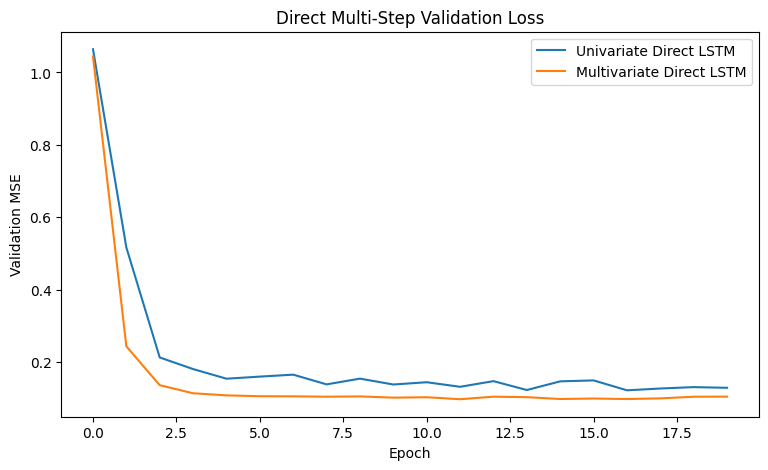

In [43]:
plt.figure(figsize=(9, 5))

plt.plot(
    uni_val_loss,
    label="Univariate Direct LSTM"
)

plt.plot(
    multi_val_loss,
    label="Multivariate Direct LSTM"
)

plt.xlabel("Epoch")
plt.ylabel("Validation MSE")
plt.title("Direct Multi-Step Validation Loss")
plt.legend()

plt.show()

## 21. Generate Direct Test Forecasts

In [44]:
def predict_model(
    model,
    X
):

    model.eval()

    X_tensor = torch.tensor(
        X
    ).to(
        device
    )

    with torch.no_grad():

        predictions = model(
            X_tensor
        )

    return predictions.cpu().numpy()

In [45]:
univariate_direct_scaled = predict_model(
    univariate_direct_model,
    X_test_uni
)

multivariate_direct_scaled = predict_model(
    multivariate_direct_model,
    X_test_multi
)

print("Direct univariate forecast shape:")
print(
    univariate_direct_scaled.shape
)

print()

print("Direct multivariate forecast shape:")
print(
    multivariate_direct_scaled.shape
)

Direct univariate forecast shape:
(553, 24)

Direct multivariate forecast shape:
(553, 24)


## 22. Convert Forecasts Back to Demand Units

In [46]:
demand_mean = feature_means[
    "demand"
]

demand_std = feature_stds[
    "demand"
]

actual_test = (
    y_test_uni
    * demand_std
    + demand_mean
)

univariate_direct_predictions = (
    univariate_direct_scaled
    * demand_std
    + demand_mean
)

multivariate_direct_predictions = (
    multivariate_direct_scaled
    * demand_std
    + demand_mean
)

## 23. Seasonal-Naive Multi-Step Baseline

For each 24-hour forecast horizon, predict the demand observed exactly one day earlier.

Because the input history contains the previous 72 hours, the relevant previous-day values are available inside each input window.

In [47]:
seasonal_naive_scaled = X_test_uni[
    :,
    -24:,
    0
]

seasonal_naive_predictions = (
    seasonal_naive_scaled
    * demand_std
    + demand_mean
)

print("Seasonal-naive forecast shape:")
print(
    seasonal_naive_predictions.shape
)

Seasonal-naive forecast shape:
(553, 24)


## 24. Overall Multi-Step Metrics

In [48]:
def calculate_mae(
    actual,
    predicted
):

    return np.mean(
        np.abs(
            actual - predicted
        )
    )


def calculate_rmse(
    actual,
    predicted
):

    return np.sqrt(
        np.mean(
            (
                actual - predicted
            ) ** 2
        )
    )

In [49]:
comparison_rows = []

forecast_sets = [
    (
        "Seasonal Naive",
        seasonal_naive_predictions
    ),
    (
        "Direct Univariate LSTM",
        univariate_direct_predictions
    ),
    (
        "Direct Multivariate LSTM",
        multivariate_direct_predictions
    )
]

for name, predictions in forecast_sets:

    comparison_rows.append(
        {
            "Model": name,
            "MAE": calculate_mae(
                actual_test,
                predictions
            ),
            "RMSE": calculate_rmse(
                actual_test,
                predictions
            )
        }
    )

comparison_table = pd.DataFrame(
    comparison_rows
)

print(
    comparison_table.sort_values(
        by="MAE"
    )
)

                      Model       MAE      RMSE
1    Direct Univariate LSTM  2.664007  3.314507
2  Direct Multivariate LSTM  2.679374  3.312006
0            Seasonal Naive  2.796419  3.456763


## 25. Horizon-Wise MAE

A 24-step forecast should not be summarized only by one average number.

For each horizon:

$$
h = 1,2,\ldots,24
$$

calculate error separately.

In [50]:
horizon_numbers = np.arange(
    1,
    forecast_horizon + 1
)

seasonal_horizon_mae = []

univariate_horizon_mae = []

multivariate_horizon_mae = []

for horizon_index in range(
    forecast_horizon
):

    actual_horizon = actual_test[
        :,
        horizon_index
    ]

    seasonal_horizon = seasonal_naive_predictions[
        :,
        horizon_index
    ]

    univariate_horizon = univariate_direct_predictions[
        :,
        horizon_index
    ]

    multivariate_horizon = multivariate_direct_predictions[
        :,
        horizon_index
    ]

    seasonal_horizon_mae.append(
        calculate_mae(
            actual_horizon,
            seasonal_horizon
        )
    )

    univariate_horizon_mae.append(
        calculate_mae(
            actual_horizon,
            univariate_horizon
        )
    )

    multivariate_horizon_mae.append(
        calculate_mae(
            actual_horizon,
            multivariate_horizon
        )
    )

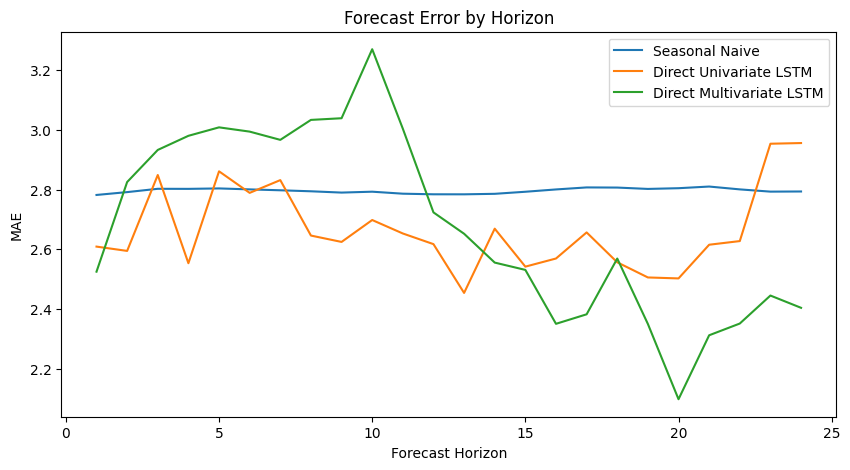

In [51]:
plt.figure(figsize=(10, 5))

plt.plot(
    horizon_numbers,
    seasonal_horizon_mae,
    label="Seasonal Naive"
)

plt.plot(
    horizon_numbers,
    univariate_horizon_mae,
    label="Direct Univariate LSTM"
)

plt.plot(
    horizon_numbers,
    multivariate_horizon_mae,
    label="Direct Multivariate LSTM"
)

plt.xlabel("Forecast Horizon")
plt.ylabel("MAE")
plt.title("Forecast Error by Horizon")
plt.legend()

plt.show()

## 26. Visualize One 24-Hour Forecast

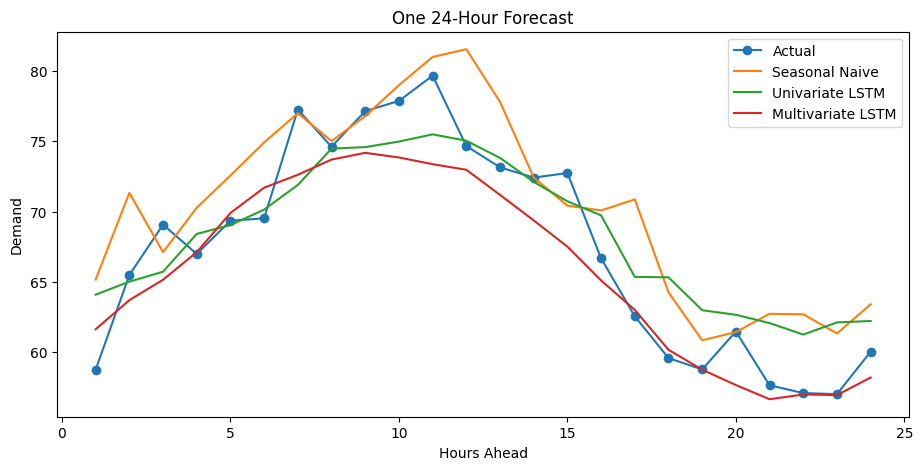

In [52]:
sample_index = 20

actual_sample = actual_test[
    sample_index
]

seasonal_sample = seasonal_naive_predictions[
    sample_index
]

univariate_sample = univariate_direct_predictions[
    sample_index
]

multivariate_sample = multivariate_direct_predictions[
    sample_index
]

plt.figure(figsize=(11, 5))

plt.plot(
    horizon_numbers,
    actual_sample,
    label="Actual",
    marker="o"
)

plt.plot(
    horizon_numbers,
    seasonal_sample,
    label="Seasonal Naive"
)

plt.plot(
    horizon_numbers,
    univariate_sample,
    label="Univariate LSTM"
)

plt.plot(
    horizon_numbers,
    multivariate_sample,
    label="Multivariate LSTM"
)

plt.xlabel("Hours Ahead")
plt.ylabel("Demand")
plt.title("One 24-Hour Forecast")
plt.legend()

plt.show()

# Part II — Recursive Forecasting

## 27. What Is Recursive Forecasting?

A one-step model is repeatedly reused:

```text
history
  ↓
predict t+1
  ↓
append prediction
  ↓
predict t+2
  ↓
append prediction
  ↓
...
```

The major problem is **error accumulation** because later predictions depend on earlier predicted values.

## 28. Create Single-Step Univariate Windows

In [53]:
def create_single_step_windows(
    values,
    lookback
):

    X = []

    y = []

    for start_index in range(
        0,
        len(values) - lookback
    ):

        end_index = (
            start_index + lookback
        )

        X.append(
            values[
                start_index:end_index
            ]
        )

        y.append(
            values[
                end_index
            ]
        )

    X = np.array(
        X,
        dtype=np.float32
    )

    y = np.array(
        y,
        dtype=np.float32
    )

    X = X[
        :,
        :,
        None
    ]

    return X, y

In [54]:
X_train_single, y_train_single = create_single_step_windows(
    train_target,
    lookback
)

X_validation_single, y_validation_single = create_single_step_windows(
    validation_target,
    lookback
)

print("Single-step X shape:")
print(
    X_train_single.shape
)

print()

print("Single-step y shape:")
print(
    y_train_single.shape
)

Single-step X shape:
(2952, 72, 1)

Single-step y shape:
(2952,)


## 29. One-Step LSTM

In [55]:
class SingleStepLSTM(
    nn.Module
):

    def __init__(
        self,
        hidden_size=64
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.output_layer = nn.Linear(
            hidden_size,
            1
        )


    def forward(
        self,
        x
    ):

        output_sequence, states = self.lstm(
            x
        )

        hidden_state = states[
            0
        ]

        final_hidden = hidden_state[
            -1
        ]

        prediction = self.output_layer(
            final_hidden
        )

        return prediction

## 30. Train the One-Step Model

In [56]:
single_train_loader = create_loader(
    X_train_single,
    y_train_single[
        :,
        None
    ],
    batch_size,
    True
)

single_validation_loader = create_loader(
    X_validation_single,
    y_validation_single[
        :,
        None
    ],
    batch_size,
    False
)

single_step_model = SingleStepLSTM()

single_step_model, single_train_loss, single_val_loss, single_training_time = train_multistep_model(
    single_step_model,
    single_train_loader,
    single_validation_loader
)

Epoch: 1 | Train: 0.66293 | Validation: 0.43778
Epoch: 2 | Train: 0.14951 | Validation: 0.17218
Epoch: 3 | Train: 0.1149 | Validation: 0.13609
Epoch: 4 | Train: 0.10299 | Validation: 0.13601
Epoch: 5 | Train: 0.09892 | Validation: 0.12704
Epoch: 6 | Train: 0.09772 | Validation: 0.12392
Epoch: 7 | Train: 0.09916 | Validation: 0.13241
Epoch: 8 | Train: 0.09309 | Validation: 0.10682
Epoch: 9 | Train: 0.09594 | Validation: 0.1196
Epoch: 10 | Train: 0.09385 | Validation: 0.10438
Epoch: 11 | Train: 0.09224 | Validation: 0.1021
Epoch: 12 | Train: 0.09201 | Validation: 0.09842
Epoch: 13 | Train: 0.08928 | Validation: 0.09777
Epoch: 14 | Train: 0.09451 | Validation: 0.10543
Epoch: 15 | Train: 0.09168 | Validation: 0.11364
Epoch: 16 | Train: 0.09161 | Validation: 0.10611
Epoch: 17 | Train: 0.08971 | Validation: 0.09787
Epoch: 18 | Train: 0.09091 | Validation: 0.10265
Epoch: 19 | Train: 0.08789 | Validation: 0.10138
Epoch: 20 | Train: 0.09044 | Validation: 0.10774


## 31. Recursive 24-Step Forecast Function

In [57]:
def recursive_forecast(
    model,
    initial_window,
    forecast_horizon
):

    model.eval()

    history = initial_window.copy()

    predictions = []

    for step in range(
        forecast_horizon
    ):

        model_input = torch.tensor(
            history[
                -lookback:
            ],
            dtype=torch.float32
        )

        model_input = model_input.view(
            1,
            lookback,
            1
        )

        model_input = model_input.to(
            device
        )

        with torch.no_grad():

            next_prediction = model(
                model_input
            )

        next_value = next_prediction.item()

        predictions.append(
            next_value
        )

        history = np.append(
            history,
            next_value
        )

    return np.array(
        predictions,
        dtype=np.float32
    )

## 32. Generate Recursive Forecasts for a Subset

Recursive forecasting is computationally slower because each horizon requires another model call.

For demonstration, we evaluate a subset of test origins.

In [58]:
number_of_recursive_samples = min(
    150,
    len(
        X_test_uni
    )
)

recursive_scaled_predictions = []

for sample_index in range(
    number_of_recursive_samples
):

    initial_window = X_test_uni[
        sample_index,
        :,
        0
    ]

    forecast = recursive_forecast(
        single_step_model,
        initial_window,
        forecast_horizon
    )

    recursive_scaled_predictions.append(
        forecast
    )

recursive_scaled_predictions = np.array(
    recursive_scaled_predictions
)

recursive_predictions = (
    recursive_scaled_predictions
    * demand_std
    + demand_mean
)

recursive_actual = actual_test[
    :number_of_recursive_samples
]

print("Recursive forecast shape:")
print(
    recursive_predictions.shape
)

Recursive forecast shape:
(150, 24)


## 33. Recursive Error by Horizon

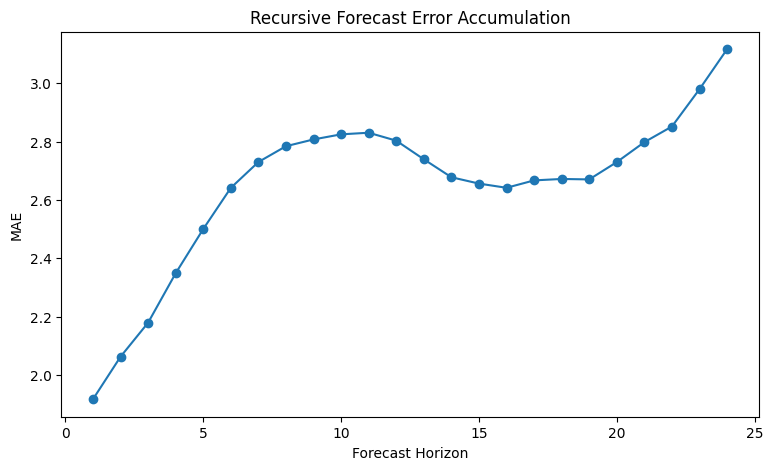

In [59]:
recursive_horizon_mae = []

for horizon_index in range(
    forecast_horizon
):

    mae = calculate_mae(
        recursive_actual[
            :,
            horizon_index
        ],
        recursive_predictions[
            :,
            horizon_index
        ]
    )

    recursive_horizon_mae.append(
        mae
    )

plt.figure(figsize=(9, 5))

plt.plot(
    horizon_numbers,
    recursive_horizon_mae,
    marker="o"
)

plt.xlabel("Forecast Horizon")
plt.ylabel("MAE")
plt.title("Recursive Forecast Error Accumulation")

plt.show()

## 34. Direct vs Recursive

### Recursive

Advantages:

- one-step model can be reused,
- simple training target.

Limitations:

- error accumulation,
- later predictions depend on previous predicted values,
- inference is sequential.

### Direct Multi-Output

Advantages:

- all horizons predicted together,
- no recursive feedback during inference,
- efficient batch generation.

Limitations:

- larger output space,
- must learn relationships among many horizons simultaneously.

## 35. Sequence-to-Sequence Forecasting

A more general architecture uses:

```text
Encoder
   ↓
Temporal representation
   ↓
Decoder
   ↓
Forecast sequence
```

This can support:

- variable forecast horizons,
- teacher forcing during training,
- autoregressive decoding,
- attention between decoder steps and historical representations.

The exact Seq2Seq architecture is not required to understand the direct-vs-recursive distinction developed here.

## 36. Future Covariates

A multivariate model becomes more complex when future covariates are available.

Example:

```text
Past demand
Past temperature
Future weather forecast
Calendar
        ↓
Future demand
```

Important distinction:

```text
known future covariate       ✓
actual future test value     ✗ if unavailable at forecast time
```

This is a common source of unrealistic forecasting results.

## 37. What Does Multivariate Improvement Mean?

If the multivariate model improves over the univariate model, do not immediately conclude:

> More variables are always better.

Ask:

- Are the variables genuinely predictive?
- Are they available when forecasting?
- Does performance improve at all horizons or only some?
- Does the model become more sensitive to distribution shift?
- Is the added complexity operationally justified?

## 38. Limitations

This notebook uses:

- historical covariates only,
- LSTM-based forecasting,
- deterministic point forecasts,
- fixed 24-hour horizon,
- fixed lookback,
- no future weather forecast,
- no probabilistic output.

The next notebook explores **attention-based forecasting and pretrained time-series foundation models**.

## 39. Key Takeaways

- Multi-step forecasting is fundamentally different from one-step forecasting.
- Recursive methods can accumulate their own errors.
- Direct models predict the complete horizon jointly.
- Multivariate models use several features at every historical timestep.
- Future covariates are only valid if they are genuinely available.
- Horizon-wise evaluation reveals where forecast quality degrades.
- A single aggregate metric can hide important multi-step behavior.